In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output
#from google.colab import Hamiltonian
#import build_H

In [ ]:
number_of_qubits = 8

In [ ]:
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [ ]:
one = np.array([[1., 0.],[0.,1.]])
pauli_1 = np.array([[0.,1.],[1.,0.]])
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]])
pauli_3 = np.array([[1.,0.],[0., -1.]])
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [ ]:
m = 0.1

def Get_H(m):
    res_XY = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_mass = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_iter = torch.zeros(2**number_of_qubits, 2**number_of_qubits)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)

    #print(res_XY)

    # mass term
    for i in range(1, number_of_qubits + 1):
        mass = one
        for j in range(1, number_of_qubits - i):
            mass = TensorProduct(one, mass)
        if i == number_of_qubits:
            mass = pauli_3
        else:
            mass = TensorProduct(pauli_3, mass)
        for j in range(1, i):
            mass = TensorProduct(one, mass)
    
        res_mass += (-1)**i * (torch.from_numpy(mass))
    
       
    #print(res_mass)

    # iteraction term
    for i in range(1,number_of_qubits ):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(1, i + 1):
        
            ite = one
        
            for k in range(1, number_of_qubits - j):
                ite = TensorProduct(one, ite)
            if j == number_of_qubits:
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(1, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(1,number_of_qubits):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    
    return 1/4*res_iter + res_XY + m/2*res_mass 
H = Get_H(m)
I = torch.zeros(2**number_of_qubits,2**number_of_qubits)
for i in range(2**number_of_qubits):
    I[i][i] = 1.579100
#H = H +I
#print(H)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
def matrix_element_iter_new(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    C = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       

    C[j,j] = -(batch_new[j]*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        C[j,j] += batch_new[j,i]*s[j]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I    
    return (C + One)/4
                
            
def matrix_element_xy(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    
    place = torch.zeros(number_of_qubits -1,2)
    C = torch.zeros(batch_size, batch_size)
    
    for i in range(number_of_qubits-1):
        place[i][0]= i
        place[i][1] = i+1
    outt = torch.arange(batch_size)
    for i in outt:
        for j in outt:
            true = (torch.nonzero(batch_new[i] != batch_new[j])).reshape(-1)
            if (true.shape[0] == 2) and ((true == place).prod(dim = 1).sum()):
                C[i,j] = 1 -batch_new[i,true[0]]*batch_new[i,true[1]]
    return C/2

def matrix_element_m(batch):

    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    
    t = torch.arange(0,number_of_qubits,1).to(device)
    
    batch_new[:,t] *= (-1)**(t+1)
    
    M = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1)
    M[j,j] = -batch_new.sum(dim = 1)
        #N+= M
    return m/2*M

def matrix_element_xy_new_7(batch):
    batch_new = torch.clone(batch)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    res = batch_new.unsqueeze(1) != batch_new
    
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
    return C/2

def matrix(batch):               
    return  matrix_element_iter_new(batch) + matrix_element_xy_new_7(batch) + matrix_element_m(batch)

In [ ]:
class MaskedLinear_MADE(nn.Linear):
    def __init__(self, in_channels, out_channels, n, bias, exclusive):
        super(MaskedLinear_MADE, self).__init__(in_channels * n , out_channels * n , bias) #in n == 1 then returns nan
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n = n
        self.exclusive = exclusive
        #self.n = 1
        
        self.register_buffer('mask', torch.ones([self.n] * 2))
        if self.exclusive:
            self.mask = 1 - torch.triu(self.mask)
        else:
            self.mask = torch.tril(self.mask)
        #print(self.mask)
        self.mask = torch.cat([self.mask] * in_channels, dim=1)
        self.mask = torch.cat([self.mask] * out_channels, dim=0)
        #print(self.mask)
        self.weight.data *= self.mask

        # Correction to Xavier initialization
        self.weight.data *= torch.sqrt(self.mask.numel() / self.mask.sum())

    def forward(self, x):
        return nn.functional.linear(x, self.mask * self.weight, self.bias)

    def extra_repr(self):
        return (super(MaskedLinear, self).extra_repr() +
                ', exclusive={exclusive}'.format(**self.__dict__))



In [ ]:
def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

In [ ]:
class MyMaskedLayer_MADE(nn.Module):
    def __init__(self, size_in, size_out, n, bias, exclusive):
        super().__init__()
        
        self.size_in = size_in * n 
        self.size_out = size_out * n
        self.n = n
        self.is_bias = bias
        self.exclusive = exclusive
        
        weights = torch.Tensor(size_out*n, size_in*n)
        self.weights = nn.Parameter(weights)  # nn.Parameter is a Tensor that's a module parameter.
        # initialize weights and biases
        nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5)) # weight init
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weights)
        bound = 1 / math.sqrt(fan_in)
        
        if self.is_bias:
            bias = torch.Tensor(size_out*n)
            self.bias = nn.Parameter(bias)
            nn.init.uniform_(self.bias, -bound, bound)  # bias init

            
        self.register_buffer('mask', torch.ones([self.n] * 2))
        #self.mask = torch.ones([self.n] * 2)
        if self.exclusive:
            self.mask = 1 - torch.triu(self.mask)
        else:
            self.mask = torch.tril(self.mask)
        #print(self.mask)
        self.mask = torch.cat([self.mask] * size_in, dim=1)
        self.mask = torch.cat([self.mask] * size_out, dim=0)
        
        self.weights.data *= self.mask
        #print(self.mask, self.weights.data,)
        
        
    def forward(self, x):
        self.weights.data *= self.mask
        w_times_x= torch.mm(x,  self.weights.t())
        if self.is_bias:
            res = torch.add(w_times_x, self.bias)  
        else:
            res = w_times_x
        return res  # w times x + b

In [ ]:
class MY_MADE_ln(nn.Module):
    
    lr = 0.001 
    N_epochs = 100000
    
    def __init__(self):
        super(MY_MADE_ln,self).__init__()
        #self.Linear0 = MaskedLinear_MADE(1, 5, number_of_qubits, bias = False, exclusive=True)
        #self.Linear1 = MaskedLinear_MADE(5, 6, number_of_qubits, bias = False, exclusive=False)
        #self.Linear2 = MaskedLinear_MADE(6, 1, number_of_qubits, bias = False, exclusive=False)
        self.Linear0 = MyMaskedLayer_MADE(1,5,number_of_qubits, False, True)
        self.Linear1 = MyMaskedLayer_MADE(5,20,number_of_qubits, False, False)
        self.Linear2 = MyMaskedLayer_MADE(20,1,number_of_qubits, False, False)
        #self.Linear0 = nn.Linear(number_of_qubits, 5*number_of_qubits)
        #self.Linear1 = nn.Linear(5*number_of_qubits, 20*number_of_qubits)
        #self.Linear2 = nn.Linear(20*number_of_qubits, number_of_qubits)
        
        self.Linear5 = nn.Linear(number_of_qubits*20,number_of_qubits)
        self.epsilon = 0.00001
         
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.bn0 = nn.BatchNorm1d(5*number_of_qubits)
        self.bn1 = nn.BatchNorm1d(20*number_of_qubits)
        
        self.lnsigmoid = nn.LogSigmoid()
        self.elu = nn.ELU()
        self.softsign = nn.Softsign()
        
    def forward(self,a):
        x = self.Linear0(a)
        x = self.elu(x)
        x = self.bn0(x)
        
        x = self.Linear1(x)
        x = self.elu(x)
        x = self.bn1(x)
        
        b = self.Linear2(x)
        b[a == 1] = self.lnsigmoid(b[a == 1])
        b[a == 0] = torch.log(torch.abs(1 + 0.000001 - self.sigmoid(b[a==0])))
        
        y = self.Linear5(x)
        y = self.softsign(x)*2*math.pi
        return b,y
    
    
    def loss(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi, phase = new(out)
        #print(psi.shape, phase.shape)
        
        psi = psi.sum(dim = 1)
        psi = torch.exp(psi)
        psi = torch.sqrt(psi)
        phase = phase.sum(dim = 1)
        
        psi_real = psi *torch.cos(phase.view(psi.shape[0])) 
        psi_imag = psi *torch.sin(phase.view(psi.shape[0]))

        M = matrix(out)
        #print(M)
        E = torch.matmul(torch.transpose(psi_real.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_real)) + torch.matmul(torch.transpose(psi_imag.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_imag))
        #E = torch.matmul(torch.transpose(psi.view(out.shape[0],1), 0, 1), torch.matmul(M, psi))
        return E

    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.9) 
        distance = []
        count = 0
        previous = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000,20000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            count += 1
            
            loss_curr = self.loss(inp)
      
            if math.isnan(loss_curr):
                print(loss_curr)
                break
                
            if i == self.N_epochs - 1:
                print(loss_curr)
            
            loss_curr.backward()
            
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).detach().cpu().numpy())# To stop a tensor from tracking history, you can call .detach() 
            
            if count == 1000:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                #print(new(inp))
                print('Epoch-{0} lr: {1}'.format(i, optimizer.param_groups[0]['lr']))
                count = 0
        return distance   

In [ ]:
print(number_of_qubits)

8


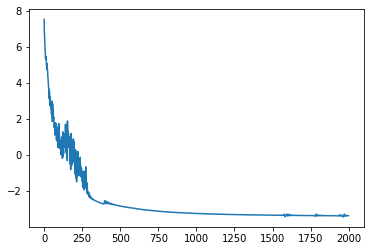




  2%|▏         | 2000/100000 [00:46<55:54, 29.21it/s]


  2%|▏         | 2005/100000 [00:46<49:53, 32.74it/s]

tensor([-3.3518], device='cuda:0', grad_fn=<AddBackward0>)
Epoch-1999 lr: 0.001





  2%|▏         | 2010/100000 [00:46<45:42, 35.73it/s]


  2%|▏         | 2015/100000 [00:46<43:00, 37.97it/s]


  2%|▏         | 2020/100000 [00:46<40:35, 40.22it/s]


  2%|▏         | 2025/100000 [00:46<38:52, 42.00it/s]


  2%|▏         | 2030/100000 [00:46<37:36, 43.41it/s]


  2%|▏         | 2035/100000 [00:46<38:45, 42.13it/s]


  2%|▏         | 2040/100000 [00:46<38:31, 42.37it/s]


  2%|▏         | 2045/100000 [00:47<37:35, 43.44it/s]


  2%|▏         | 2050/100000 [00:47<36:37, 44.58it/s]


  2%|▏         | 2055/100000 [00:47<36:06, 45.21it/s]


  2%|▏         | 2060/100000 [00:47<36:04, 45.25it/s]


  2%|▏         | 2065/100000 [00:47<36:20, 44.91it/s]


  2%|▏         | 2070/100000 [00:47<35:57, 45.39it/s]


  2%|▏         | 2075/100000 [00:47<37:14, 43.82it/s]


  2%|▏         | 2080/100000 [00:47<39:04, 41.76it/s]


  2%|▏         | 2085/100000 [00:47<37:44, 43.24it/s]


  2%|▏         | 2090/100000 [00:48<37:26, 43.59it/s]


  2%|▏         | 2095/100000 [00:48<36:55, 44

tensor([nan], device='cuda:0', grad_fn=<AddBackward0>)


NameError: ignored

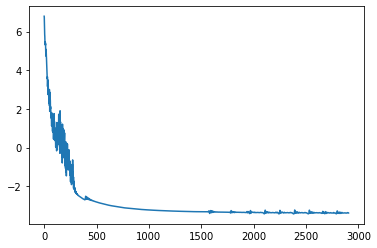

In [ ]:
new = MY_MADE_ln().to(device)
batch = torch.clone(basis).to(device)
#print(batch)
m = 0.1

dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))
psi = new(basis).prod(dim = 1).reshape(1,16)
res = torch.matmul(psi, torch.matmul(H, torch.transpose(psi, 0, 1)))
print('ML solution ={}'.format(res))
#print('exact solution ={}'.format(new.loss_classic(new(basis).prod(dim = 1))))